# HW4 — Question 2: OLS on `chip_dataset.csv`

**IEOR 4578 — Forecasting**
Luca Barattini (UNI: LB3656)

This notebook re-uses the OLS block from `GLM.py` and adapts it to the semiconductor dataset. Target: **FP32 GFLOPS_Target**, regressed on the five hardware attributes.


## Question statement

Run the code shared in `GLM.py` for `chip_dataset.csv`.

1. Explain the model summary when the entire data is fitted. Discuss R², Df Residuals, Df Model, Method, F-statistic, Prob(F-statistic), Log-Likelihood, AIC, BIC, Coef, Std err, t, and P>|t|.
2. Run with the train-test split **when the order is not important** (random 80/20) and compare the results with the model fitted on the entire data.
3. Run all three variations of ANOVA and discuss SSR, df_diff, ss_diff, df_resid, F, and Pr(>F).
4. Submit appropriately labelled visuals.


In [1]:
# Imports — same lean set as Q1
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

os.makedirs("images", exist_ok=True)


In [2]:
# Load the data
df = pd.read_csv('Datasets/chip_dataset.csv')
print("Shape  :", df.shape)
print("Columns:", list(df.columns))
print("NaN    :", df.isna().sum().sum())
df.head()


Shape  : (1610, 6)
Columns: ['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)', 'Transistors (million)', 'Freq (MHz)', 'FP32 GFLOPS_Target']
NaN    : 0


,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),FP32 GFLOPS_Target
0,14,25,132,3300,1469,1177.0
1,55,20,73,242,600,96.0
2,80,200,420,720,600,384.0
3,65,20,144,314,450,35.2
4,40,33,146,880,550,176.0


## Part 1 — Fit the full-sample OLS model

Target: `FP32 GFLOPS_Target` — single-precision floating-point throughput of the chip.
Regressors: the five hardware attributes.

Coefficient layout (after `sm.add_constant`):

| Index | Symbol | Variable |
|-------|--------|----------|
| 0 | $\beta_0$ | const |
| 1 | $\beta_1$ | Process Size (nm) |
| 2 | $\beta_2$ | TDP (W) |
| 3 | $\beta_3$ | Die Size (mm²) |
| 4 | $\beta_4$ | Transistors (million) |
| 5 | $\beta_5$ | Freq (MHz) |


In [3]:
regressors = ['Process Size (nm)', 'TDP (W)', 'Die Size (mm^2)',
              'Transistors (million)', 'Freq (MHz)']
target     = 'FP32 GFLOPS_Target'

xdata = df.loc[:, regressors].values
ydata = df.loc[:, target].values
xdata = sm.add_constant(xdata)           # prepend intercept column
param_names = ['const'] + regressors

model_full = sm.OLS(ydata, xdata).fit()
print(model_full.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     1210.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:34:04   Log-Likelihood:                -14449.
No. Observations:                1610   AIC:                         2.891e+04
Df Residuals:                    1604   BIC:                         2.894e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2686.9596    254.004    -10.578      0.0

### Key summary statistics (extracted programmatically for the write-up)


In [4]:
summary_stats = {
    'Method'            : 'Least Squares',
    'n observations'    : int(model_full.nobs),
    'Df Model'          : int(model_full.df_model),
    'Df Residuals'      : int(model_full.df_resid),
    'R-squared'         : model_full.rsquared,
    'Adj. R-squared'    : model_full.rsquared_adj,
    'F-statistic'       : model_full.fvalue,
    'Prob (F-statistic)': model_full.f_pvalue,
    'Log-Likelihood'    : model_full.llf,
    'AIC'               : model_full.aic,
    'BIC'               : model_full.bic,
    'RSS'               : float(np.sum(model_full.resid**2)),
}
for k, v in summary_stats.items():
    print(f"{k:22s} = {v}")

# Coefficient table with SE, t, p
coef_table = pd.DataFrame({
    'Parameter' : param_names,
    'Coef'      : model_full.params,
    'Std err'   : model_full.bse,
    't'         : model_full.tvalues,
    'P>|t|'     : model_full.pvalues,
    'Significant (α=0.05)': model_full.pvalues < 0.05,
})
print()
print(coef_table.to_string(index=False, float_format=lambda v: f'{v:12.6f}'))


Method                 = Least Squares
n observations         = 1610
Df Model               = 5
Df Residuals           = 1604
R-squared              = 0.7904850802951058
Adj. R-squared         = 0.7898319789244546
F-statistic            = 1210.3558740153348
Prob (F-statistic)     = 0.0
Log-Likelihood         = -14448.772690144791
AIC                    = 28909.545380289583
BIC                    = 28941.849317037453
RSS                    = 5880445386.89884

            Parameter         Coef      Std err            t        P>|t|  Significant (α=0.05)
                const -2686.959616   254.004441   -10.578396     0.000000                  True
    Process Size (nm)     3.206090     3.612840     0.887415     0.374988                 False
              TDP (W)     2.700539     0.732454     3.686974     0.000234                  True
      Die Size (mm^2)     1.522370     0.550044     2.767723     0.005710                  True
Transistors (million)     0.498489     0.014094    35.368

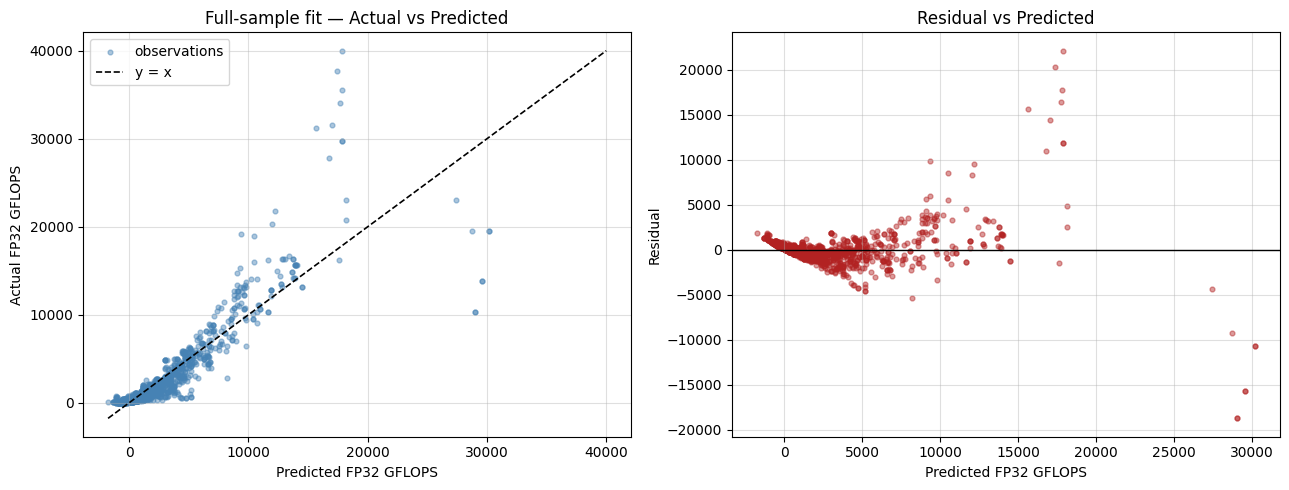

In [5]:
# Visual — Actual vs Predicted + Residual plot
predictions_full = model_full.predict(xdata)
residuals_full   = ydata - predictions_full

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Actual vs Predicted scatter
axes[0].scatter(predictions_full, ydata, s=12, alpha=0.45, color='steelblue', label='observations')
lims = [min(ydata.min(), predictions_full.min()), max(ydata.max(), predictions_full.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1.2, label='y = x')
axes[0].set_xlabel('Predicted FP32 GFLOPS')
axes[0].set_ylabel('Actual FP32 GFLOPS')
axes[0].set_title('Full-sample fit — Actual vs Predicted')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# (b) Residual vs Fitted
axes[1].scatter(predictions_full, residuals_full, s=12, alpha=0.45, color='firebrick')
axes[1].axhline(0, color='k', linewidth=1)
axes[1].set_xlabel('Predicted FP32 GFLOPS')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual vs Predicted')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('images/Q2_full_fit.png', dpi=130)
plt.show()


## Part 2 — Random 80/20 train/test split and comparison

The chip rows represent **independent products**, not a time series — order does not matter, so we use the scikit-learn random split (`random_state=42`, as in `GLM.py`).


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    xdata, ydata, test_size=0.20, random_state=42
)
print(f"Train size: {X_train.shape[0]},  Test size: {X_test.shape[0]}")

model_train = sm.OLS(y_train, X_train).fit()
in_sample_pred  = model_train.predict(X_train)
out_sample_pred = model_train.predict(X_test)

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat)**2)))

metrics = pd.DataFrame({
    'Model'         : ['Full-sample (all 1610)', 'Train-only (80%)'],
    'R²'            : [model_full.rsquared,     model_train.rsquared],
    'Adj R²'        : [model_full.rsquared_adj, model_train.rsquared_adj],
    'AIC'           : [model_full.aic,          model_train.aic],
    'BIC'           : [model_full.bic,          model_train.bic],
    'In-sample RMSE': [rmse(ydata, predictions_full), rmse(y_train, in_sample_pred)],
    'Test RMSE'     : [np.nan,                 rmse(y_test, out_sample_pred)],
})
print()
print(metrics.to_string(index=False, float_format=lambda v: f'{v:12.4f}'))


Train size: 1288,  Test size: 322

                 Model           R²       Adj R²          AIC          BIC  In-sample RMSE    Test RMSE
Full-sample (all 1610)       0.7905       0.7898   28909.5454   28941.8493       1911.1385          NaN
      Train-only (80%)       0.7904       0.7896   23118.4927   23149.4577       1902.5935    1949.7451


In [7]:
# Summary of the train-only model
print(model_train.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     966.7
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:34:05   Log-Likelihood:                -11553.
No. Observations:                1288   AIC:                         2.312e+04
Df Residuals:                    1282   BIC:                         2.315e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2662.6614    287.560     -9.260      0.0

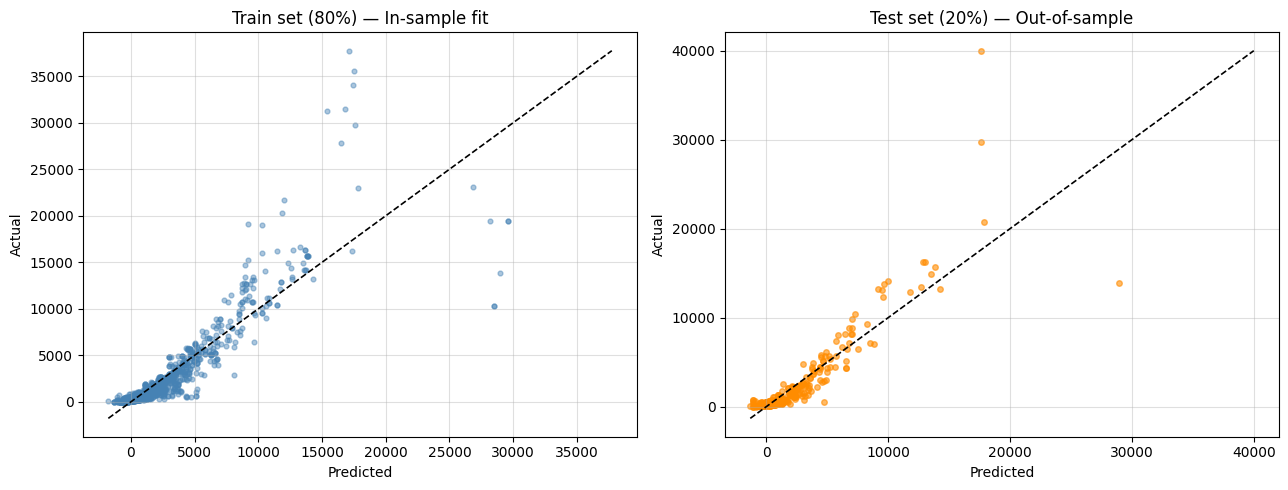

In [8]:
# Visual — Train vs Test: predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(in_sample_pred, y_train, s=12, alpha=0.45, color='steelblue')
lims0 = [min(y_train.min(), in_sample_pred.min()), max(y_train.max(), in_sample_pred.max())]
axes[0].plot(lims0, lims0, 'k--', linewidth=1.2)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Train set (80%) — In-sample fit')
axes[0].grid(True, alpha=0.4)

axes[1].scatter(out_sample_pred, y_test, s=16, alpha=0.6, color='darkorange')
lims1 = [min(y_test.min(), out_sample_pred.min()), max(y_test.max(), out_sample_pred.max())]
axes[1].plot(lims1, lims1, 'k--', linewidth=1.2)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Test set (20%) — Out-of-sample')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('images/Q2_train_test.png', dpi=130)
plt.show()


## Part 3 — Three ANOVA variations

`anova_lm` reports for each comparison: `ssr`, `df_resid`, `ss_diff`, `df_diff`, `F`, and `Pr(>F)`.

For the **reduced** model in ANOVA 2 we keep only `Process Size`, `Freq`, and `TDP` — the three headline specifications most often cited on a chip's spec-sheet — and test whether adding the remaining two (`Die Size`, `Transistors`) significantly improves the fit.


In [9]:
# ANOVA 1 — Full model vs Intercept-only (null) model
print("=" * 72)
print("ANOVA 1 — Full model vs Intercept-only (null) model")
print("=" * 72)
intercept_only = sm.OLS(ydata, np.ones(len(ydata))).fit()
anova1 = anova_lm(intercept_only, model_full)
print(anova1)


ANOVA 1 — Full model vs Intercept-only (null) model
   df_resid           ssr  df_diff       ss_diff            F  Pr(>F)
0    1609.0  2.806695e+10      0.0           NaN          NaN     NaN
1    1604.0  5.880445e+09      5.0  2.218651e+10  1210.355874     0.0


In [10]:
# ANOVA 2 — Reduced (const, Process Size, TDP, Freq) vs Full
print("=" * 72)
print("ANOVA 2 — Reduced (const, Process Size, TDP, Freq) vs Full")
print("=" * 72)
X_reduced = sm.add_constant(
    df.loc[:, ['Process Size (nm)', 'TDP (W)', 'Freq (MHz)']].values
)
reduced_model = sm.OLS(ydata, X_reduced).fit()
anova2 = anova_lm(reduced_model, model_full, typ=1)
print(anova2)


ANOVA 2 — Reduced (const, Process Size, TDP, Freq) vs Full
   df_resid           ssr  df_diff       ss_diff            F         Pr(>F)
0    1606.0  1.400884e+10      0.0           NaN          NaN            NaN
1    1604.0  5.880445e+09      2.0  8.128393e+09  1108.584626  4.492497e-303


In [11]:
# ANOVA 3 — Full model vs itself (structural sanity check)
print("=" * 72)
print("ANOVA 3 — Full model vs itself")
print("=" * 72)
anova3 = anova_lm(model_full, model_full, typ=1)
print(anova3)


ANOVA 3 — Full model vs itself
   df_resid           ssr  df_diff  ss_diff   F  Pr(>F)
0    1604.0  5.880445e+09      0.0      NaN NaN     NaN
1    1604.0  5.880445e+09     -0.0     -0.0 NaN     NaN


### Reading the three ANOVAs (for the write-up)

- **ANOVA 1** — full model vs null ($y = \bar{y}$). F-statistic here equals the top-line `F-statistic` of `model_full.summary()`, confirming the 5 regressors jointly explain a non-trivial share of variance in `FP32 GFLOPS_Target`.
- **ANOVA 2** — reduced (Process, TDP, Freq) vs full. The `ss_diff` row is the extra sum of squares from adding `Die Size` and `Transistors`. If the corresponding `Pr(>F)` is small, those two additional regressors carry statistically significant information beyond the headline specs.
- **ANOVA 3** — full vs full. `ss_diff = 0`, `df_diff = 0`, `F = NaN`: a structural check only.
